# Instruments

While `opticam` was primarily designed for use with the OPTICAM-MX instrument, it includes an interface for compatibility with other instruments. In this notebook, we will explore this interface.

## Generating observations from a new instrument

First, let's generate some observations that are not compatible with the instruments currently supported by `opticam`. For the data, we'll generate a 1 s $U$-band exposure from an instrument that has a gain of 100 electrons/ADU. We'll set the time of the observation to 00:00 on January 1st, 2026, with a pointing of 0 RA, 0 DEC:

In [ ]:
from pathlib import Path

from photutils.datasets import make_100gaussians_image
from astropy.io import fits
import numpy as np


out_dir = Path('out')

image = make_100gaussians_image()

hdu = fits.PrimaryHDU(image)  # image data

hdu.header['FILTER'] = 'U'  # the observation filter
hdu.header['BINNING'] = '1 1'  # the image binning (i.e., 1x1)
hdu.header['GAIN'] = 100.  # the detector gain in adu/photon
hdu.header['EXPTIME'] = 1.  # the exposure time in seconds
hdu.header['RA'] = '0'  # the RA of the image in degrees
hdu.header['DEC'] = '0'  # the DEC of the image in degrees
hdu.header["DATE-OBS"] = f"2026-01-01T00:00:00.000"  # observation timestamp

save_path = out_dir / 'data' / 'simple'  # directory to which image will be saved

# create save directory if it does not already exist
if not save_path.is_dir():
    save_path.mkdir(parents=True)

# save image
file_path = save_path / 'image.fits.gz'
hdu.writeto(
    file_path,
    overwrite=True,
    )

Let's take a look at one of these images:

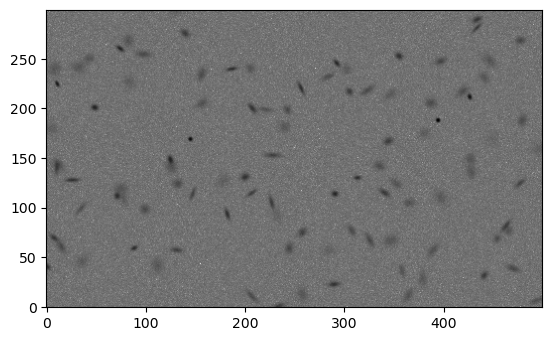

In [ ]:
from astropy.visualization import simple_norm
from matplotlib import pyplot as plt


# get image data from file
with fits.open(file_path) as hdul:
    data = np.asarray(hdul[0].data, dtype=np.float64)

fig, ax = plt.subplots()

im = ax.imshow(
    data,
    norm=simple_norm(data, stretch='log'),
    cmap='Greys',
    origin='lower',
    )

plt.show()

The image looks good.

Let's see what happens when we try to use the OPTICAM-MX instrument to reduce these data. Before performing reduction with a particular instrument, it's a good idea to call the instrument's `run_checks()` method. This method takes a path to an image and runs a series of checks to ensure that the data are consistent with those produced by the instrument:

In [ ]:
import opticam


instrument = opticam.OPTICAM_MX()
instrument.run_checks(file_path)

[OPTICAM] ERROR: OPTICAM_MX.exptime_kw (EXPOSURE) is not a valid header keyword for file out/data/simple/image.fits.gz.
[OPTICAM] ERROR: OPTICAM_MX.dateobs_kw (UT) is not a valid header keyword for file out/data/simple/image.fits.gz.
[OPTICAM] ERROR: OPTICAM_MX.pixel_scales does not contain a corresponding value for the filter U.
[OPTICAM] ERROR: Failed to parse the MJD of the image due the following exception: "Keyword 'UT' not found.". This is likely due to an incorrect value being passed to dateobs_kw and/or your images do not give timestamps in FITS format. In the latter case, you will need to define a custom instrument with a custom get_mjd() method. See (TODO: link) for details.

[OPTICAM] WARNING: OPTICAM_MX.dark_curr_kw (DARKCURR) is not a valid header keyword for file out/data/simple/image.fits.gz. If no dark current is listed in the image headers, you will need to use a `opticam.DarkNoiseCorrector` instance to correct for dark noise. See (TODO: link) for details.

[OPTICAM] O

In this case, we can see that we have several errors, and one warning:
- The first error is caused by `OPTICAM_MX` using a different header keyword for the image's exposure time. Typically, the keyword "EXPTIME" is used to identify the image's exposure time; this is the case for these data. However, `OPTICAM_MX` uses the "EXPOSURE" keyword instead.
- The second error is again caused by a header keyword mismatch, this time for the timestamp keyword. Typically, the keyword "DATE-OBS" is used to identify the image's timestamp; this is the case for these data. However, `OPTICAM_MX` uses the "UT" keyword instead.
- The third error is due to the data using the $U$-band filter, which is not supported by `OPTICAM_MX` and therefore has no corresponding pixel scale.
- The final error is related to the second error: the Modified Julian Date (MJD) of the image cannot be inferred because of the timestamp keyword mismatch between these data and `OPTICAM_MX`.
- The warning is due to these data not containing a "DARKCURR" keyword in the header. `opticam` can use the dark current value (represented by the header keyword "DARKCURR") to infer and subtract the dark noise from the image. If this keyword does not exist, then dark noise can be removed using a `DarkNoiseCorrector` instance instead (see the [corrections tutorial](applying_corrections.ipynb) for more details). This warning can therefore be ignored in this case.

There are also a number of other issues with using `OPTICAM_MX` that didn't result in any errors being raised. Let's look at `OPTICAM_MX` to see what the instrument represents:

In [4]:
print(instrument)

OPTICAM_MX(location=<EarthLocation (-2352558.38786513, -4940313.54119147, 3271528.71037222) m>, pixel_scales={'u': 0.1397, "u'": 0.1397, 'g': 0.1397, "g'": 0.1397, 'r': 0.1406, "r'": 0.1406, 'i': 0.1661, "i'": 0.1661, 'z': 0.1661, "z'": 0.1661}, read_noise=1.1, binning_kw='BINNING', dark_curr_kw='DARKCURR', exptime_kw='EXPOSURE', filter_kw='FILTER', gain_kw='GAIN', dateobs_kw='UT', ra_kw='RA', dec_kw='DEC')


We can see that `OPTICAM_MX` has a predefined position, a dictionary of pixel scales for each possible filter, a read noise value, and a number of header keywords. Many of these parameters are likely not be representative of our new instrument. Notably, location and read noise values. The location of the instrument is used when applying Barycentric corrections, and the read noise is used to calculate the total photometric error. Our new instrument therefore needs to redefine many of these parameters for accurate results.

There are two ways to define a new instrument. The simplest is to generate a configuration file template, edit the necessary values, and then use that configuration file to define a new instrument. This works well provided the instrument adheres to the conventional FITS header keywords (discussed in more detail below) and represents values in FITS format. If this is not the case, then you will need to define your instrument as a class that inherits from the `opticam.Instrument` base class.

## Defining an instrument from a configuration file

In this case, our data use conventional FITS header keywords and all values are given in FITS format. Explicitly:
- The corresponding filter is given by the "FILTER" keyword.
- The image binning is given by the "BINNING" keyword.
- The detector's gain value is given by the "GAIN" keyword in electrons/ADU.
- The corresponding exposure time is given by the "EXPTIME" keyword in seconds.
- The corresponding RA is given by the "RA" keyword.
- The corresponding DEC is given by the "DEC" keyword.
- The corresponding timestamp is given by the "DATE-OBS" keyword in FITS format (YYYY-MM-DDTHH:MM:SS.sss).

If any of these values were given by different keywords or were in different units/formats, then it would be necessary to define the instrument using a custom class instead of from configuration file.

To create a configuration file, it is suggested to generate and then edit a configuration template. Configuration templates can be generated using the `generate_instrument_json_template()` function. This function takes a directory path and writes an `instrument_template.json` file to that directory:

In [5]:
opticam.generate_instrument_json_template(out_dir)

Let's take a look at the contents of this template:

In [ ]:
import json


with open(out_dir / 'instrument_template.json', 'r') as file:
    config_dict = json.load(file)

for k, v in config_dict.items():
    print(k)
    print(v)
    print()

longitude
0.0

_longitude_description
The East longitude of the observatory in degrees.

latitude
0.0

_latitude_description
The latitude of the observatory in degrees.

height
0.0

_height_description
The height of the observatory in meters.

pixel_scales
{'filter_1': 0.0, 'filter_2': 0.0}

_pixel_scales_description
The pixel-scale in arcsec/pixel for each filter.

read_noise
0.0

_read_noise_description
The detector's readout noise in electrons/pixel.

binning_kw
BINNING

_binning_kw_description
The header keyword that corresponds to the binning mode.

dark_curr_kw
DARKCURR

_dark_curr_kw_description
The header keyword that corresponds to the detector's dark current in electrons/pixel.

exptime_kw
EXPTIME

_exptime_kw_description
The header keyword that corresponds to the exposure time in seconds.

filter_kw
FILTER

_filter_kw_description
The header keyword that corresponds to the image filter.

gain_kw
GAIN

_gain_kw_description
The header keyword that corresponds to the detector's 

As we can see, the template lists a number of parameters that can be configured, including descriptions for each parameter. In practise, one would probably edit this template in their preferred text editor. For demonstrative purposes, however, I will edit the dictionary in this notebook.

For this example, I'll ignore the location parameters (longitude, latitude, and height), as well as the read noise, since these values vary on an instrument-by-instrument basis. The only parameter that needs changing to prevent errors is `pixel_scales`, since the `exptime_kw` and `timestamp_kw` parameters of the template are already set to the conventional "EXPTIME" and "DATE-OBS" values, respectively:

In [7]:
config_dict['pixel_scales'] = {
    'U': 1.0,  # 1.0 arcsec/pixel
    }

Let's save this edited config file under a new name:

In [8]:
with open(out_dir / 'new_instrument_config.json', 'w') as file:
    json.dump(
        config_dict,
        file,
        indent=4,
        )

Now we can use this file to create our instrument using the `from_json()` method of `opticam.Instrument`. This method takes either a path to a config JSON file, or a config can be passed directly:

In [9]:
# using the saved config file
new_instrument = opticam.Instrument.from_json(file_path=out_dir / 'new_instrument_config.json')

# using the config dictionary
new_instrument_alt = opticam.Instrument.from_json(config=config_dict)

new_instrument == new_instrument_alt

True

In [10]:
assert new_instrument == new_instrument_alt

Let's take a look at our new instrument and check it's using the correct values:

In [11]:
print(new_instrument)

Instrument(location=<EarthLocation (6378137., 0., 0.) m>, pixel_scales={'U': 1.0}, read_noise=0.0, binning_kw='BINNING', dark_curr_kw='DARKCURR', exptime_kw='EXPTIME', filter_kw='FILTER', gain_kw='GAIN', dateobs_kw='DATE-OBS', ra_kw='RA', dec_kw='DEC')


Looks good!

New let's run the instrument checks for this new instrument:

In [12]:
new_instrument.run_checks(file_path)

[OPTICAM] WARNING: Instrument.dark_curr_kw (DARKCURR) is not a valid header keyword for file out/data/simple/image.fits.gz. If no dark current is listed in the image headers, you will need to use a `opticam.DarkNoiseCorrector` instance to correct for dark noise. See (TODO: link) for details.

[OPTICAM] Instrument sucessfully passed all checks.
[OPTICAM] Instrument triggered a warning during 1 check. Warnings may be ignored provided their caveats are satisfied.


No more errors! We still have a warning about the dark current keyword, but we can safely ignore this for now.

As noted above, creating instruments from a configuration template works well provided the instrument follows the convetional FITS header structure. Now let's take a look at what to do if this is not the case:

In [13]:
from astropy.time import Time

image = make_100gaussians_image()

hdu = fits.PrimaryHDU(image)  # image data

hdu.header['FILTER'] = 'I'  # the observation filter
hdu.header['BINNING'] = '2x2'  # the image binning
hdu.header['GAIN'] = 500.  # the detector gain in adu/photon
hdu.header['EXPOSURE'] = 1.  # the exposure time in seconds
hdu.header['RA'] = '12 30 49.4'  # the RA of the image in degrees
hdu.header['DEC'] = '+12 23 28.0'  # the DEC of the image in degrees

fits_time = f"2026-01-01T00:00:00.000"  # observation timestamp
mjd_time = float(np.asarray(Time(fits_time, format='fits').mjd))  # convert time from FITS format to MJD
hdu.header['DATE-OBS'] = mjd_time

save_path = out_dir / 'data' / 'custom'  # directory to which image will be saved

# create save directory if it does not already exist
if not save_path.is_dir():
    save_path.mkdir(parents=True)

# save image
new_file_path = save_path / 'image.fits.gz'
hdu.writeto(
    new_file_path,
    overwrite=True,
    )

These new data are very similar to the previous example, but replace the "EXPTIME" keyword with "EXPOSURE", and store the image's timestamp in MJD format instead of the conventional FITS format.

Let's look at the header of this image:

In [14]:
header = fits.getheader(new_file_path)
print(repr(header))

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  500                                                  
NAXIS2  =                  300                                                  
EXTEND  =                    T                                                  
FILTER  = 'I       '                                                            
BINNING = '2x2     '                                                            
GAIN    =                500.0                                                  
EXPOSURE=                  1.0                                                  
RA      = '12 30 49.4'                                                          
DEC     = '+12 23 28.0'                                                         
DATE-OBS=              61041

Predictably, these new data will fail with both `OPTICAM_MX` and our newly created instrument:

In [15]:
instrument.run_checks(new_file_path)

[OPTICAM] ERROR: OPTICAM_MX.dateobs_kw (UT) is not a valid header keyword for file out/data/custom/image.fits.gz.
[OPTICAM] ERROR: OPTICAM_MX.pixel_scales does not contain a corresponding value for the filter I.
[OPTICAM] ERROR: Failed to parse the MJD of the image due the following exception: "Keyword 'UT' not found.". This is likely due to an incorrect value being passed to dateobs_kw and/or your images do not give timestamps in FITS format. In the latter case, you will need to define a custom instrument with a custom get_mjd() method. See (TODO: link) for details.

[OPTICAM] WARNING: OPTICAM_MX.dark_curr_kw (DARKCURR) is not a valid header keyword for file out/data/custom/image.fits.gz. If no dark current is listed in the image headers, you will need to use a `opticam.DarkNoiseCorrector` instance to correct for dark noise. See (TODO: link) for details.

[OPTICAM] OPTICAM_MX failed 3 checks.
[OPTICAM] OPTICAM_MX triggered a warning during 1 check. Warnings may be ignored provided the

In [16]:
new_instrument.run_checks(new_file_path)

[OPTICAM] ERROR: Instrument.exptime_kw (EXPTIME) is not a valid header keyword for file out/data/custom/image.fits.gz.
[OPTICAM] ERROR: Instrument.pixel_scales does not contain a corresponding value for the filter I.
[OPTICAM] ERROR: Failed to parse the MJD of the image due the following exception: Input values did not match the format class fits:
ValueError: Time 61041.0 does not match fits format. This is likely due to an incorrect value being passed to dateobs_kw and/or your images do not give timestamps in FITS format. In the latter case, you will need to define a custom instrument with a custom get_mjd() method. See (TODO: link) for details.

[OPTICAM] WARNING: Instrument.dark_curr_kw (DARKCURR) is not a valid header keyword for file out/data/custom/image.fits.gz. If no dark current is listed in the image headers, you will need to use a `opticam.DarkNoiseCorrector` instance to correct for dark noise. See (TODO: link) for details.

[OPTICAM] Instrument failed 3 checks.
[OPTICAM] In

## Defining an instrument from the opticam.Instrument base class

To reduce these data, we cannot create a new instrument from a configuration file because the timestamps are not in FITS format. Instead, we need to define a custom class that inherits from `opticam.Instrument` and implement a custom `get_mjd()` method:

In [ ]:
%%writefile custom_instrument.py
from astropy.io import fits

import opticam


class CustomInstrument(opticam.Instrument):
    
    def get_mjd(self, file_path=None, header=None):
        
        if header is None:
            header = fits.getheader(file_path)
        
        return float(header[self.dateobs_kw])

Overwriting custom_routines.py


Due to compatibility issues, routines defined inside of IPython notebooks cannot be used by `multiprocessing` (used by `opticam`). To overcome this issue, we have used the `%%writefile` magic command to write our `CustomInstrument` class to a temporary module called `custom_routines.py`, such that it can be imported by `multiprocessing`. This is required in Python $\geq$ 3.14.

The `get_mjd()` method of an `Instrument` instance takes two inputs: `file_path` and `header`. `file_path` corresponds to the file path to the FITS file, while `header` corresponds to the header of the FITS file. When called, only one of these values will be passed, depending on whether the image has already been opened or not, and so both parameters should assume default values (i.e., `None`). The value returned by `get_mjd()` should be the MJD of the image as a `float`.

In this example, the MJD is given by the header, so it can be returned directly. If the header gives the timestamp in an alternative format, it may be convenient to use the [`astropy.time`](https://docs.astropy.org/en/stable/time/index.html) module to convert it to MJD.

To instance this `CustomInstrument`, we can again generate and edit a configuration template:

In [ ]:
from custom_instrument import CustomInstrument

with open(out_dir / 'instrument_template.json', 'r') as file:
    custom_config = json.load(file)

custom_config['exptime_kw'] = 'EXPOSURE'  # change EXPTIME keyword
custom_config['pixel_scales'] = {
    'I': 1.0,  # 1.0 arcsec/pixel
    }

custom_instrument = CustomInstrument.from_json(config=custom_config)

print(custom_instrument)

CustomInstrument(location=<EarthLocation (6378137., 0., 0.) m>, pixel_scales={'I': 1.0}, read_noise=0.0, binning_kw='BINNING', dark_curr_kw='DARKCURR', exptime_kw='EXPOSURE', filter_kw='FILTER', gain_kw='GAIN', dateobs_kw='DATE-OBS', ra_kw='RA', dec_kw='DEC')


In [19]:
custom_instrument.run_checks(new_file_path)

[OPTICAM] WARNING: CustomInstrument.dark_curr_kw (DARKCURR) is not a valid header keyword for file out/data/custom/image.fits.gz. If no dark current is listed in the image headers, you will need to use a `opticam.DarkNoiseCorrector` instance to correct for dark noise. See (TODO: link) for details.

[OPTICAM] CustomInstrument sucessfully passed all checks.
[OPTICAM] CustomInstrument triggered a warning during 1 check. Warnings may be ignored provided their caveats are satisfied.


Alteratively, we could define the instrument by hardcoding the required parameters, which is a bit more convenient for reusing this instrument many times:

In [22]:
%%writefile custom_instrument_class.py
from astropy.coordinates import EarthLocation
from astropy.io import fits

import opticam


__all__ = ['CustomInstrumentClass']


class CustomInstrumentClass(opticam.Instrument):
    
    def __init__(
        self,
        location = EarthLocation.from_geodetic(
            lon=0.0,  # observatory longitude in degrees
            lat=0.0,  # observatory East latitude in degrees
            height=0.0,  # observatory height in meters
            ),
        pixel_scales = {
            'I': 1.0,
            },
        read_noise = 0.0,
        exptime_kw = 'EXPOSURE',
        ):
        
        super().__init__(
            location=location,
            pixel_scales=pixel_scales,
            read_noise=read_noise,
            exptime_kw=exptime_kw,
            )
    
    def get_mjd(
        self,
        file_path=None,
        header=None,
        ):
        
        if header is None:
            header = fits.getheader(file_path)
        
        return float(header[self.dateobs_kw])

Writing custom_instrument_class.py


In [23]:
from custom_instrument_class import CustomInstrumentClass

custom_instrument_class = CustomInstrumentClass()

print(custom_instrument_class)

CustomInstrumentClass(location=<EarthLocation (6378137., 0., 0.) m>, pixel_scales={'I': 1.0}, read_noise=0.0, binning_kw='BINNING', dark_curr_kw='DARKCURR', exptime_kw='EXPOSURE', filter_kw='FILTER', gain_kw='GAIN', dateobs_kw='DATE-OBS', ra_kw='RA', dec_kw='DEC')


In [24]:
custom_instrument_class.run_checks(new_file_path)

[OPTICAM] WARNING: CustomInstrumentClass.dark_curr_kw (DARKCURR) is not a valid header keyword for file out/data/custom/image.fits.gz. If no dark current is listed in the image headers, you will need to use a `opticam.DarkNoiseCorrector` instance to correct for dark noise. See (TODO: link) for details.

[OPTICAM] CustomInstrumentClass sucessfully passed all checks.
[OPTICAM] CustomInstrumentClass triggered a warning during 1 check. Warnings may be ignored provided their caveats are satisfied.


While creating custom instrument classes is more advanced than editing a configuration template, it is far more configurable. Additionally, instrument classes only need to be created once, and can then be reused indefinitely (unless the instrument changes the format of its data products). If you write a class for an instrument, we encourage you to consider opening a [pull request](https://github.com/OPTICAM-instrument/opticam/pulls) to merge your instrument into `opticam`.

## Gotchas

Below, we discuss some common problems you might encounter when trying to write a custom `Instrument` class for your instrument.

### My images don't contain a binning keyword. What should I do?

If your images do not contain a binning keyword, you'll need to fake it by writing a custom `get_binning()` method. If your instrument only supports one binning mode, then the `get_binning()` method can simply return an arbitrary string:

In [25]:
%%writefile instrument_without_binning.py
import opticam


class InstrumentWithoutBinning(opticam.Instrument):
    
    def get_binning(self, file_path=None, header=None):
        
        return '1x1'

Writing instrument_without_binning.py


In [26]:
from instrument_without_binning import InstrumentWithoutBinning

instrument_without_binning = InstrumentWithoutBinning.from_json(config=config_dict)

print(instrument_without_binning)

InstrumentWithoutBinning(location=<EarthLocation (6378137., 0., 0.) m>, pixel_scales={'U': 1.0}, read_noise=0.0, binning_kw='BINNING', dark_curr_kw='DARKCURR', exptime_kw='EXPTIME', filter_kw='FILTER', gain_kw='GAIN', dateobs_kw='DATE-OBS', ra_kw='RA', dec_kw='DEC')


Like the `get_mjd()` method, the `get_binning()` takes one of two inputs: either `file_path` or `header`. In this example, however, neither are needed. The value returned by `get_binning()` can be any string that uniquely identifies the binning mode used to create the image.

Now let's generate an image without a binning keyword:

In [27]:
image = make_100gaussians_image()

hdu = fits.PrimaryHDU(image)  # image data

hdu.header['FILTER'] = 'U'
hdu.header['GAIN'] = 1.
hdu.header['EXPTIME'] = 1.
hdu.header['RA'] = '12 30 49.4'
hdu.header['DEC'] = '+12 23 28.0'
hdu.header['DATE-OBS'] = f"2026-01-01T00:00:00.000"

new_file_path = out_dir / 'data' / 'no_binnning'
hdu.writeto(
    new_file_path,
    overwrite=True,
    )

When we check a previous instrument that would otherwise work:

In [28]:
new_instrument.run_checks(new_file_path)

[OPTICAM] ERROR: failed to read image binning for file out/data/no_binnning due to the exception "Keyword 'BINNING' not found.". This is either due to an incorrect value being passed to binning_kw and/or your images do not contain a binning keyword. In the latter case, you will need to define a custom instrument with a custom get_binning() method. See (TODO: link) for details.

[OPTICAM] WARNING: Instrument.dark_curr_kw (DARKCURR) is not a valid header keyword for file out/data/no_binnning. If no dark current is listed in the image headers, you will need to use a `opticam.DarkNoiseCorrector` instance to correct for dark noise. See (TODO: link) for details.

[OPTICAM] Instrument failed 1 check.
[OPTICAM] Instrument triggered a warning during 1 check. Warnings may be ignored provided their caveats are satisfied.


We see that an error is raised. With our new instrument, however:

In [29]:
instrument_without_binning.run_checks(new_file_path)

[OPTICAM] WARNING: InstrumentWithoutBinning.dark_curr_kw (DARKCURR) is not a valid header keyword for file out/data/no_binnning. If no dark current is listed in the image headers, you will need to use a `opticam.DarkNoiseCorrector` instance to correct for dark noise. See (TODO: link) for details.

[OPTICAM] InstrumentWithoutBinning sucessfully passed all checks.
[OPTICAM] InstrumentWithoutBinning triggered a warning during 1 check. Warnings may be ignored provided their caveats are satisfied.


We don't get any errors.

Alternatively, the binning information may be inferrable from other keywords (e.g., `NAXIS1` and `NAXIS2`). In this case, you may want your custom `get_binning()` method to infer the binning mode from these parameters. This way, `opticam` will be able to check that all images in a given directory use the same binning mode.

For example, if your instrument has a resolution of 2048x2048, then you can infer the binning mode by dividing the instrument's resolution by the image resolution:

In [30]:
%%writefile instrument_with_inferred_binning.py
import opticam


class InstrumentWithInferredBinning(opticam.Instrument):
    
    def get_binning(self, file_path=None, header=None):
        
        header = fits.getheader(file_path)
        
        x_size = int(header['NAXIS1'])
        y_size = int(header['NAXIS2'])
        
        # divide instrument resolution by image resolution
        x_binning = 2048 // x_size
        y_binning = 2048 // y_size
        
        return f'{x_binning}x{y_binning}'


Writing instrument_with_inferred_binning.py


In [31]:
from instrument_with_inferred_binning import InstrumentWithInferredBinning


instrument_with_inferred_binning = InstrumentWithInferredBinning.from_json(config=config_dict)
instrument_with_inferred_binning.run_checks(file_path=new_file_path)

[OPTICAM] ERROR: failed to read image binning for file out/data/no_binnning due to the exception name 'fits' is not defined. This is either due to an incorrect value being passed to binning_kw and/or your images do not contain a binning keyword. In the latter case, you will need to define a custom instrument with a custom get_binning() method. See (TODO: link) for details.

[OPTICAM] WARNING: InstrumentWithInferredBinning.dark_curr_kw (DARKCURR) is not a valid header keyword for file out/data/no_binnning. If no dark current is listed in the image headers, you will need to use a `opticam.DarkNoiseCorrector` instance to correct for dark noise. See (TODO: link) for details.

[OPTICAM] InstrumentWithInferredBinning failed 1 check.
[OPTICAM] InstrumentWithInferredBinning triggered a warning during 1 check. Warnings may be ignored provided their caveats are satisfied.


### My instrument has multiple cameras that use the same filters, what should I do?

If your instrument has multiple cameras that use the same filters, then you might encounter a few issues. For example, to apply flats, you'll need some way of distinguishing between cameras. The simplest way to do this is to create an `Instrument` with a custom `get_filter()` method. This method should not only read the filter of the image, but also which camera was used. For example, your instrument may include an additional `"CAMERA"` keyword in the image headers that uniquely identified which camera took the image. Let's generate a few such images.

In this example, I'll generate images from two different cameras, both of which use a $U$-band filter. For clarity, I'll make the images from the second camera slightly smaller to highlight the difference:

In [32]:
image = make_100gaussians_image()

for i in range(3):
    # image from first camera
    hdu = fits.PrimaryHDU(image)  # image data
    hdu.header['FILTER'] = 'U'
    hdu.header['CAMERA'] = '1'  # camera keyword that uniquely identifies the camera used
    hdu.header['BINNING'] = '1x1'
    hdu.header['GAIN'] = 1.
    hdu.header['DARKCURR'] = .1
    hdu.header['EXPTIME'] = 1.
    hdu.header['RA'] = '12 30 49.4'
    hdu.header['DEC'] = '+12 23 28.0'
    hdu.header['DATE-OBS'] = f"2026-01-01T00:00:0{i}.000"
    
    save_path = out_dir / 'data' / 'custom_filters'
    
    # create save directory if it does not already exist
    if not save_path.is_dir():
        save_path.mkdir(parents=True)
    
    new_file_path = save_path / f'camera_1_image_{i}.fits.gz'
    hdu.writeto(
        new_file_path,
        overwrite=True,
        )
    
    # smaller image from second camera
    hdu = fits.PrimaryHDU(image[:250, :400])  # image data
    
    hdu.header['FILTER'] = 'U'
    hdu.header['CAMERA'] = '2'  # camera keyword that uniquely identifies the camera used
    hdu.header['BINNING'] = '1x1'
    hdu.header['GAIN'] = 1.
    hdu.header['DARKCURR'] = .1
    hdu.header['EXPTIME'] = 1.
    hdu.header['RA'] = '12 30 49.4'
    hdu.header['DEC'] = '+12 23 28.0'
    hdu.header['DATE-OBS'] = f"2026-01-01T00:00:0{i}.000"
    
    new_file_path = save_path / f'camera_2_image_{i}.fits.gz'
    hdu.writeto(
        new_file_path,
        overwrite=True,
        )

We now have a total of six images taken with two different cameras that use the same filter. When reading these images, we clearly do not want to mix images between cameras since they have different shapes. We therefore need to define an `Instrument` that can disentagle these images:

In [33]:
%%writefile instrument_with_custom_filter.py
from astropy.coordinates import EarthLocation

import opticam


class InstrumentWithCustomFilter(opticam.Instrument):
    
    def __init__(
        self,
        location = EarthLocation.from_geodetic(
            lon=0.0,
            lat=0.0,
            height=0.0,
            ),
        pixel_scales = {
            'U:1': 1.0,  # pixel scale for camera 1
            'U:2': 1.5,  # pixel scale for camera 2
            },
        read_noise = 0.0,
        ):
        
        super().__init__(
            location=location,
            pixel_scales=pixel_scales,
            read_noise=read_noise,
            )
    
    def get_filter(self, file_path=None, header=None):
        
        if header is None:
            header = fits.getheader(file_path)
        
        camera = str(header['CAMERA'])
        fltr = str(header[self.filter_kw])
        
        # the returned filter includes the camera and the filter
        return f'{fltr}:{camera}'


Writing instrument_with_custom_filter.py


Notice that the new instrument includes pixel scales for both cameras using the format `[FILTER]:[CAMERA]`, and the custom `get_filter()` method combines the `"CAMERA"` keyword with the `"FILTER"` keyword using the same format. In this way, `opticam` can distinguish between the two cameras. The format is arbitrary, as long as it's clear which camera was used to take which image.

Let's use this instrument in a `Reducer` to see it in action:

[OPTICAM] out/reduced/custom_filters not found, attempting to create ...
[OPTICAM] out/reduced/custom_filters created.
[OPTICAM] InstrumentWithCustomFilter sucessfully passed all checks.


[OPTICAM] Scanning data directory: 100%|██████████|[00:04<00:00]


[OPTICAM] Binning: 1x1
[OPTICAM] Filters: U:2, U:1
[OPTICAM] 3 U:2 images.
[OPTICAM] 3 U:1 images.
[OPTICAM] DarkNoiseCorrector sucessfully passed all checks.


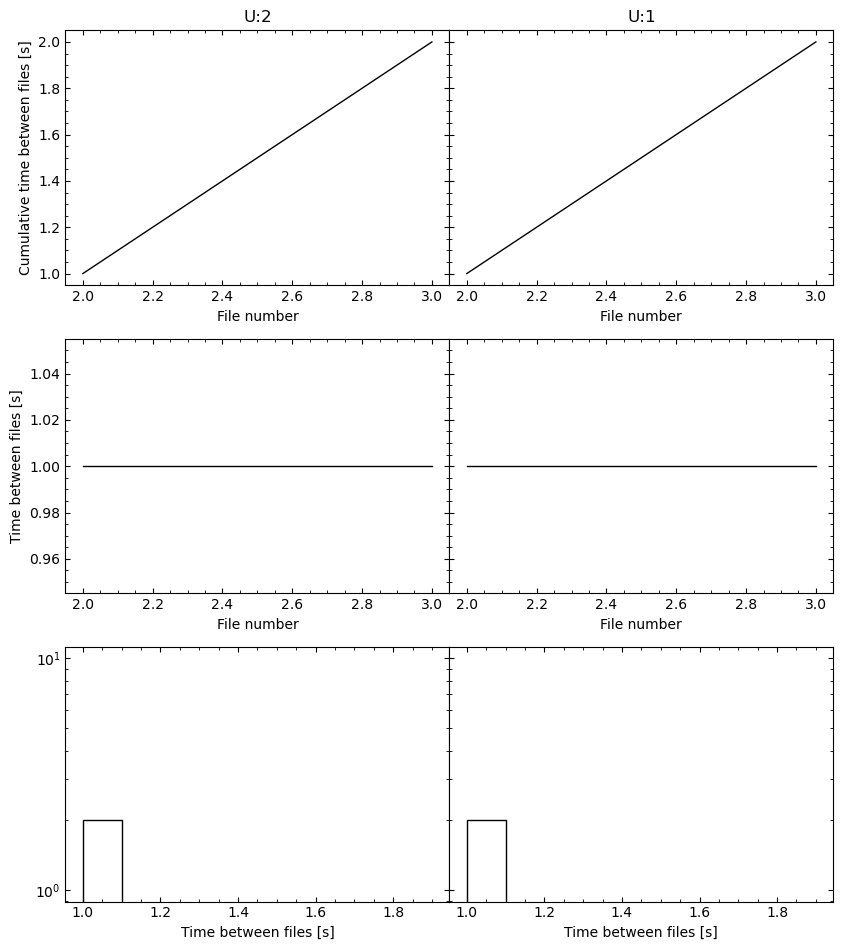

[OPTICAM] Creating source catalogs


[OPTICAM] Aligning U:2 images: 100%|██████████|[00:02<00:00]

[OPTICAM] Done.
[OPTICAM] 3 image(s) aligned.
[OPTICAM] 0 image(s) could not be aligned.



[OPTICAM] Aligning U:1 images: 100%|██████████|[00:02<00:00]


[OPTICAM] Done.
[OPTICAM] 3 image(s) aligned.
[OPTICAM] 0 image(s) could not be aligned.


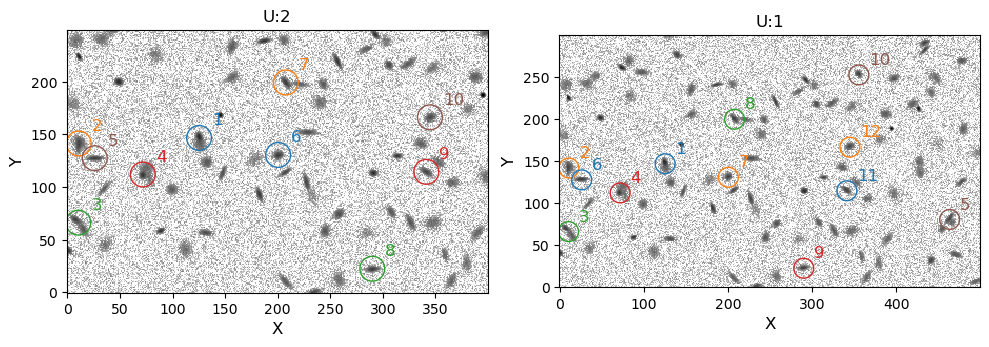

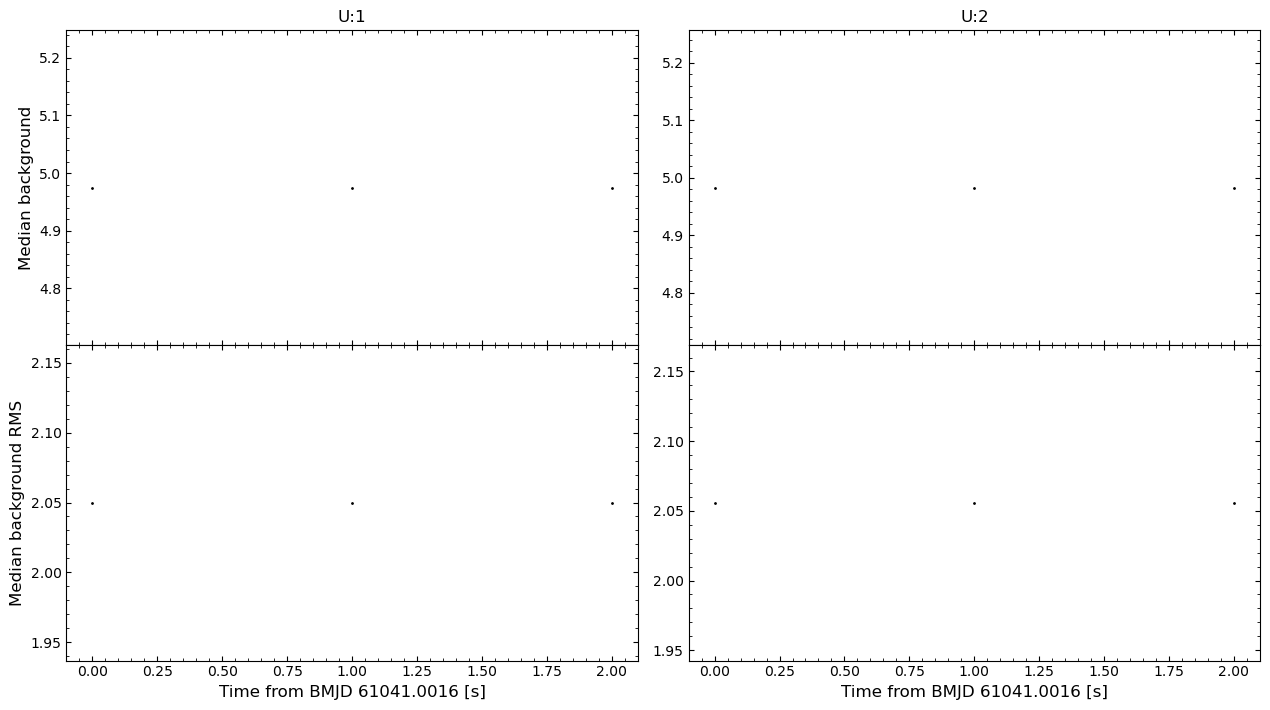

In [34]:
from instrument_with_custom_filter import InstrumentWithCustomFilter


custom_filter_reducer = opticam.Reducer(
    out_directory=out_dir / 'reduced' / 'custom_filters',
    data_directory=out_dir / 'data' / 'custom_filters',
    instrument=InstrumentWithCustomFilter(),
    show_plots=True,
    finder=opticam.DefaultFinder(npixels=32),
    background=opticam.DefaultBackground(25),
    )

custom_filter_reducer.create_catalogs(overwrite=True)

As we can see, the two cameras have been uniquely identified thanks to our custom `get_filter()` method.